In [3]:
from utils import *

In [4]:
system = fluxonium_oscillator_system(
    EJ = 1.5,
    EC = 1.46*0.5,
    EL = 0.23*0.5,
    Er = 7.13459619,
    g_strength = 0.4,
    qubit_level = 30,
    osc_level = 50,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in [1,2,3] for ol in range(30) ] \
                    + [[ql, ol] for ql in [0] for ol in range(40) ]
    )


max overlap^2 7.555410372212637e-06 below threshold for dressed state 1498 with eval 377.14063033480977
max overlap^2 2.647919044541797e-05 below threshold for dressed state 1499 with eval 377.19350057348134


In [5]:
tot_time =1000
tlist = np.linspace(0, tot_time, tot_time)

results = system.run_mesolve_on_driving_osc(
    intial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(4)],
    tlist = tlist,
    osc_decay = False,
    amp = 0.004,
)


# import pickle
# with open('pickles/sesolve_detection_results.pkl', 'wb') as file:
#     pickle.dump(results, file)

# with open('pickles/sesolve_detection_results.pkl', 'rb') as file:
#     results = pickle.load(file)

 Total run time: 181.41s*] Elapsed 181.41s / Remaining 00:00:00:00          0%           ] Elapsed 0.00s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00
 Total run time: 182.66s*] Elapsed 182.66s / Remaining 00:00:00:00
 Total run time: 182.67s*] Elapsed 182.67s / Remaining 00:00:00:00
 Total run time: 196.83s*] Elapsed 196.83s / Remaining 00:00:00:00


 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

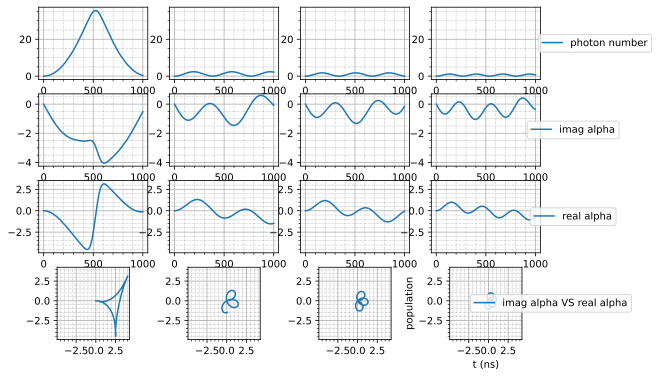

In [6]:
plot_population(results,
                system.qbt.truncated_dim,
                system.osc.truncated_dim,
                system.product_to_dressed,
                system.a,
                system.w_d,
                tlist,
                fourier=True,
                fix_ylim=True,
                plot_only_pn_alpha= True)

In [22]:
interactive_heatmap(results[0], system.product_to_dressed, system.qubit_level, system.osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=999), Output(…

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

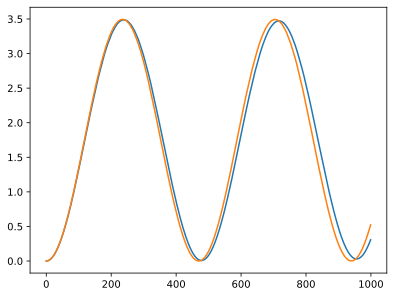

In [16]:
def get_pn_expect(result,a):
    pn_op = jnp.array((a.dag()*a).full())

    # Vectorize the function compute_expectation over the kets
    vectorized_compute_expectation = vmap(compute_expectation, in_axes=(0, None))
    vectorized_compute_expectation = jit(vectorized_compute_expectation)

    if hasattr(result, 'y'):
        states = jnp.array(result.y)  # assuming y contains JAX arrays or density matrices
    elif hasattr(result, 'states'):
        states = jnp.stack([jnp.array(q.full()) for q in result.states])  # assuming states contains QObj or density matrices

    pns_expect = vectorized_compute_expectation(states, pn_op)
    return pns_expect

pn_exp_one = get_pn_expect(results[1],system.a)
pn_exp_two = get_pn_expect(results[2],system.a)

plt.plot(pn_exp_one)
plt.plot(pn_exp_two)

In [17]:
def find_valley_index(values):
    # First, find the index of the peak
    peak_index = 0
    for i in range(1, len(values)):
        if values[i] < values[i - 1]:
            peak_index = i - 1
            break

    # Next, find the minimum value after the peak
    valley_index = peak_index + values[peak_index:].index(min(values[peak_index:]))

    return valley_index

index_of_valley_1 = find_valley_index(list(pn_exp_one))
index_of_valley_2 = find_valley_index(list(pn_exp_two))
index_of_valley_1, index_of_valley_2

(478, 470)

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

(0.0, 0.01)

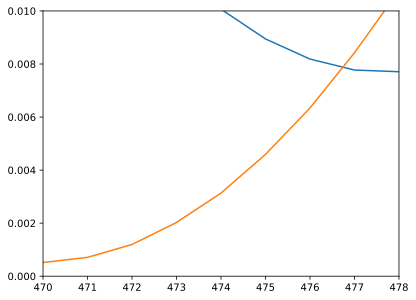

In [18]:
plt.plot(pn_exp_one)
plt.plot(pn_exp_two)
plt.xlim(min(index_of_valley_2,index_of_valley_1),max(index_of_valley_2,index_of_valley_1))
plt.ylim(0,0.01)

nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 0.9999999999847279
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 0.9999999999936757


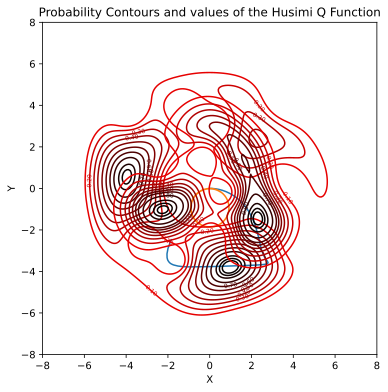

In [23]:
plt.figure(figsize=(6,6))

first_dominant_freq = find_dominant_frequency(results[0].expect[0],tlist)
 
def plot_husimi_probability_contours(dressed_state,product_to_dressed,qubit_level,osc_level):
    if dressed_state.dims[-1][0] == 1:
        dressed_state = qutip.ket2dm(dressed_state)
    dressed_dm_data = dressed_state.full()
    rho_product = np.zeros((qubit_level * osc_level, qubit_level * osc_level), dtype=complex)
    for (ql, ol), dressed_level in product_to_dressed.items():
        index1 = ql * osc_level + ol
        # Loop again to populate the density matrix
        for (ql2, ol2), dressed_level2 in product_to_dressed.items():
            index2 = ql2 * osc_level + ol2
            # TODO  the order of product_state and product_state2 doesn't make sense to me, but it produces the right result. :(
            element = dressed_dm_data[dressed_level, dressed_level2]
            rho_product[index1, index2] += element
    rho_product = qutip.Qobj(rho_product, dims=[[qubit_level, osc_level], [qubit_level, osc_level]])
    rho_coherent = rho_product.ptrace(1)

    # print(f"nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() {abs(rho_coherent - rho_coherent.dag()).data.max()}")
    print(f"nonhermicity: Frobenius norm of the difference between rho and rho dag {np.linalg.norm((rho_coherent - rho_coherent.dag()).full(), 'fro')}")
    rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())

    print(f"trace: {rho_coherent.tr()}")
    rho_coherent = rho_coherent / rho_coherent.tr()


    xvec = np.linspace(-20,20,500)

    Q_coherent = qutip.qfunc(rho_coherent, xvec, xvec)

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    X, Y = np.meshgrid(xvec, xvec)
    for prob in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.02]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = plt.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        plt.clabel(contour, inline=False, fontsize=6, fmt=fmt)

    # Q_coherent[Q_coherent < sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - 0.98))]] = None
    # plt.contourf(xvec, xvec, Q_coherent, 100)

alpha = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real)

alpha = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real)



t_idx = 250
plot_husimi_probability_contours(dressed_state=results[0].states[t_idx],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = system.qubit_level,
                                 osc_level = system.osc_level)
plot_husimi_probability_contours(dressed_state=results[1].states[t_idx],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = system.qubit_level,
                                 osc_level = system.osc_level)

plt.title("Probability Contours and values of the Husimi Q Function")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-8,8)
plt.ylim(-8,8)

plt.show()